# Stage 4 — RL Policy Evaluation vs Baselines

Compares the neural RL policy against rule-based and fixed baselines on the three required RL reporting dimensions:

| Dimension | Source | Metric |
|-----------|--------|--------|
| **Reward convergence** | `per_episode_*.csv` | `episode_return` per episode |
| **Policy stability** | `per_episode_*.csv` | `action_variance` per episode |
| **Generalization** | `per_step_*.csv` (held-out paths) | GPU frame time CDF vs. training paths |

**Per-step data** (`per_step_*.csv`): produced by `RLEvaluationLogger` in `EvalRollouts/`  
**Per-episode data** (`per_episode_*.csv`): produced by `RLEvaluationLogger` in `EvalRollouts/`  
**Baseline data** (`inference_eval_*.csv`): from `data/BaseLine/`

### Expected run labels
- `neural_rl` — RL policy with ONNX model assigned  
- `rule_based` — `RLPolicyController` fallback (fps < 45 → -0.05)  
- `fixed_default` — Unity default lodBias=1.0, no controller  
- `fixed_aggressive` — lodBias reduced, neural off  

### SSIM proxy note
`avg_screen_coverage` is used as the SSIM approximation throughout training and evaluation.
Full SSIM is unavailable at Unity runtime. This substitution is documented here and in `RLEvaluationLogger.cs`.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_style('darkgrid')
print('Libraries OK')

Libraries OK


In [2]:
BASE_DIR      = Path('../..').resolve()
EVAL_DIR      = BASE_DIR / 'data' / 'RL_Eval'
BASELINE_DIR  = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR     = BASE_DIR / 'plots' / 'Stage_4' / 'Eval'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FRAME_BUDGET_MS = 16.67   # 60 FPS
T_TARGET_MS     = 4.5     # GPU target — VAR_T_TARGET_MS

RUN_COLORS = {
    'neural_rl':        '#2196F3',   # blue
    'rule_based':       '#9C27B0',   # purple
    'fixed_default':    '#4CAF50',   # green
    'fixed_aggressive': '#FF9800',   # orange
}
DEFAULT_COLOR = '#607D8B'

print(f'EVAL_DIR     : {EVAL_DIR}')
print(f'BASELINE_DIR : {BASELINE_DIR}')
print(f'PLOTS_DIR    : {PLOTS_DIR}')

EVAL_DIR     : C:\Users\Gica\neural-lod\ml_pipeline\data\RL_Eval
BASELINE_DIR : C:\Users\Gica\neural-lod\ml_pipeline\data\BaseLine
PLOTS_DIR    : C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Eval


## 1. Load Per-Step Data
Reads `per_step_*.csv` from `Baker_Eval_3/` (RL runs) and `BaseLine/` (fixed baselines).

In [3]:
step_files_rl   = list(EVAL_DIR.glob('per_step_*.csv'))
step_files_base = list(BASELINE_DIR.glob('inference_eval_*.csv'))

print(f'RL per-step files  : {len(step_files_rl)}')
print(f'Baseline eval files: {len(step_files_base)}')

dfs = []

# RL runs (per_step CSV format from RLEvaluationLogger)
rl_step_cols = ['run_label', 'episode', 'frame', 'cpu_ms', 'gpu_ms', 'fps',
                'lod_bias', 'action_delta', 'reward_step', 'cumulative_return',
                'screen_coverage', 'screen_coverage_delta', 'recent_switch_count']

for f in step_files_rl:
    df = pd.read_csv(f)
    df['source'] = 'rl'
    dfs.append(df)

# Baseline runs (inference_eval CSV format — remap columns to common schema)
for f in step_files_base:
    df = pd.read_csv(f)
    # Remap to common column names
    rename = {
        'cpu_frame_time': 'cpu_ms',
        'gpu_frame_time': 'gpu_ms',
        'lod_bias_applied': 'lod_bias'
    }
    df = df.rename(columns=rename)
    if 'run_label' not in df.columns and 'source_file' in df.columns:
        # Infer run label from filename
        name = f.stem
        for label in ['fixed_default', 'fixed_aggressive', 'rule_based']:
            if label in name:
                df['run_label'] = label
                break
        else:
            df['run_label'] = name
    if 'episode' not in df.columns:
        df['episode'] = 0
    if 'action_delta' not in df.columns:
        df['action_delta'] = 0.0
    if 'reward_step' not in df.columns:
        df['reward_step'] = 0.0
    if 'screen_coverage' not in df.columns:
        df['screen_coverage'] = 0.0
    if 'recent_switch_count' not in df.columns:
        df['recent_switch_count'] = 0.0
    df['source'] = 'baseline'
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(
        'No eval CSVs found. Run Unity with RLEvaluationLogger enabled '
        '(neural_rl and rule_based runs) and copy per_step_*.csv files to Baker_Eval_3/.'
    )

data = pd.concat(dfs, ignore_index=True)

numeric_cols = ['episode', 'frame', 'cpu_ms', 'gpu_ms', 'fps', 'lod_bias',
                'action_delta', 'reward_step', 'cumulative_return',
                'screen_coverage', 'recent_switch_count']
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['cpu_ms', 'gpu_ms', 'fps'])

runs = sorted(data['run_label'].unique())
print(f'\nRun labels: {runs}')
print(f'Total rows: {len(data):,}')
print()
print(data.groupby('run_label').size().rename('frames'))

RL per-step files  : 2
Baseline eval files: 2

Run labels: ['fixed_aggressive', 'fixed_default', 'neural_rl']
Total rows: 15,074

run_label
fixed_aggressive    4225
fixed_default       3914
neural_rl           6935
Name: frames, dtype: int64


## 2. Load Per-Episode Data
Reads `per_episode_*.csv` from `Baker_Eval_3/` for reward convergence and stability metrics.

In [4]:
ep_files = list(EVAL_DIR.glob('per_episode_*.csv'))
print(f'Per-episode files: {len(ep_files)}')

ep_dfs = []
for f in ep_files:
    df = pd.read_csv(f)
    ep_dfs.append(df)

if ep_dfs:
    ep_data = pd.concat(ep_dfs, ignore_index=True)
    for col in ['episode', 'total_frames', 'episode_return', 'mean_gpu_ms',
                'action_mean', 'action_variance', 'switch_count_total']:
        if col in ep_data.columns:
            ep_data[col] = pd.to_numeric(ep_data[col], errors='coerce')
    ep_runs = sorted(ep_data['run_label'].unique())
    print(f'Episode-level runs: {ep_runs}')
    print(f'Total episodes    : {len(ep_data)}')
    display(ep_data.head(5))
else:
    ep_data = None
    print('No per_episode_*.csv found. Reward convergence and stability plots will be skipped.')

Per-episode files: 2
Episode-level runs: ['neural_rl']
Total episodes    : 2


,run_label,episode,total_frames,episode_return,mean_gpu_ms,mean_fps,mean_lod_bias,action_mean,action_variance,switch_count_total
0,neural_rl,0,3731,-1895.930,4.2916,0.0,1.0,-0.001233,0.000229,0
1,neural_rl,0,3204,-1635.141,4.2097,0.0,1.0,-0.001311,0.000242,0


## 3. Performance Summary Matrix

In [5]:
def pct(series, p):
    return float(np.percentile(series.dropna(), p))

rows = []
for run in runs:
    df  = data[data['run_label'] == run]
    cpu = df['cpu_ms'].dropna()
    gpu = df['gpu_ms'].dropna()
    fps = df['fps'].dropna()
    act = df['action_delta'].dropna()
    sw  = df['recent_switch_count'].dropna()
    lod = df['lod_bias'].dropna()

    lod_vals  = lod.values
    switches  = sum(1 for i in range(1, len(lod_vals))
                    if abs(lod_vals[i] - lod_vals[i-1]) > 0.001)
    dur_s     = len(df) / fps.mean() if fps.mean() > 0 else 1
    flip_rate = switches / dur_s if dur_s > 0 else 0

    rows.append({
        'run_label':       run,
        'frames':          len(df),
        'mean_cpu_ms':     round(cpu.mean(), 3),
        'p95_cpu_ms':      round(pct(cpu, 95), 3),
        'p99_cpu_ms':      round(pct(cpu, 99), 3),
        'mean_gpu_ms':     round(gpu.mean(), 3),
        'p95_gpu_ms':      round(pct(gpu, 95), 3),
        'p99_gpu_ms':      round(pct(gpu, 99), 3),
        'mean_fps':        round(fps.mean(), 2),
        'p5_fps':          round(pct(fps, 5), 2),
        'mean_lod_bias':   round(lod.mean(), 4),
        'action_std':      round(act.std(), 4),
        'lod_switches':    switches,
        'flip_rate_hz':    round(flip_rate, 3),
        'over_budget_pct': round(100 * (cpu > FRAME_BUDGET_MS).sum() / len(cpu), 1),
        'mean_screen_cov': round(df['screen_coverage'].dropna().mean(), 4)
            if 'screen_coverage' in df.columns else 0.0
    })

summary = pd.DataFrame(rows).set_index('run_label')
print('=== Performance Summary ===')
display(summary.T)

=== Performance Summary ===


run_label,fixed_aggressive,fixed_default,neural_rl
frames,4225.000,3914.000,6935.0000
mean_cpu_ms,16.666,16.666,16.6250
p95_cpu_ms,17.032,17.048,17.8060
p99_cpu_ms,17.250,17.390,24.0860
mean_gpu_ms,4.683,5.218,4.2250
p95_gpu_ms,5.657,6.402,5.1100
p99_gpu_ms,6.021,6.761,5.5480
mean_fps,60.000,60.000,61.2400
p5_fps,59.740,59.730,59.6300
mean_lod_bias,0.500,1.000,0.3050


## 4. Reward Convergence (RL Metric 1)
Episode return per episode for RL runs. A converging policy shows increasing or stabilizing returns.

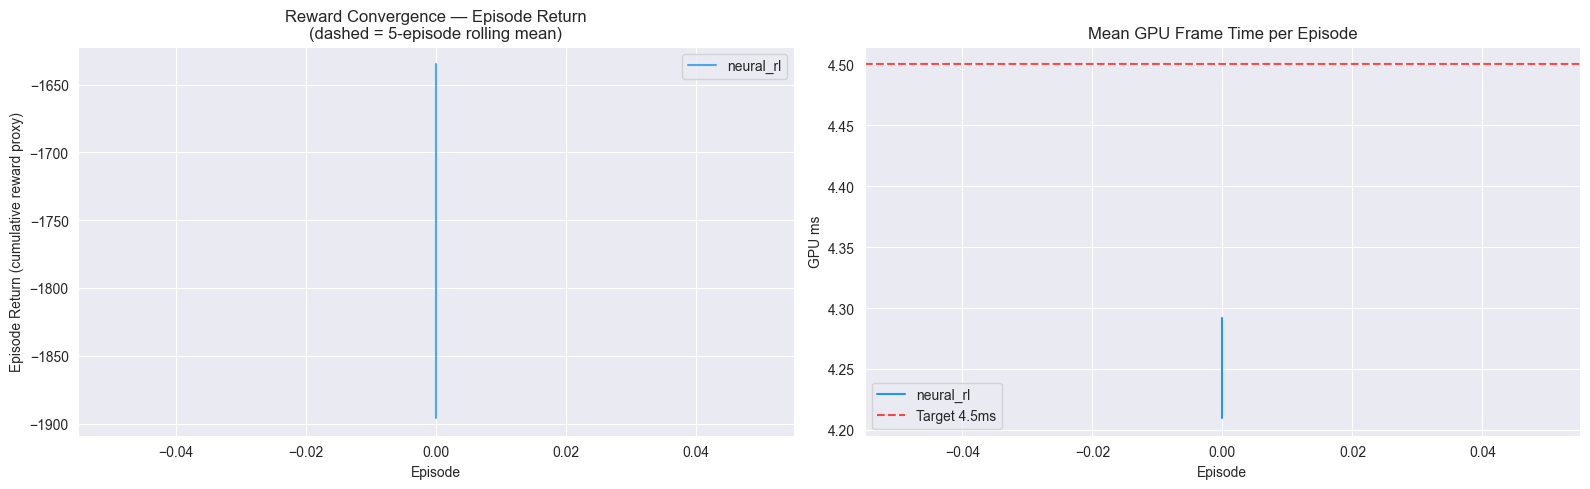

In [6]:
if ep_data is None:
    print('Skipped — no per_episode_*.csv found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Episode return per episode
    ax = axes[0]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        color = RUN_COLORS.get(run, DEFAULT_COLOR)
        ax.plot(df_ep['episode'], df_ep['episode_return'],
                label=run, color=color, lw=1.5, alpha=0.8)
        # Rolling mean
        if len(df_ep) >= 5:
            roll = df_ep['episode_return'].rolling(5, min_periods=1).mean()
            ax.plot(df_ep['episode'], roll,
                    color=color, lw=2.5, linestyle='--', alpha=0.9)
    ax.set_title('Reward Convergence — Episode Return\n(dashed = 5-episode rolling mean)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Episode Return (cumulative reward proxy)')
    ax.legend()

    # Mean GPU per episode
    ax = axes[1]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        if 'mean_gpu_ms' in df_ep.columns:
            ax.plot(df_ep['episode'], df_ep['mean_gpu_ms'],
                    label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), lw=1.5)
    ax.axhline(T_TARGET_MS, color='red', linestyle='--', alpha=0.7,
               label=f'Target {T_TARGET_MS}ms')
    ax.set_title('Mean GPU Frame Time per Episode')
    ax.set_xlabel('Episode')
    ax.set_ylabel('GPU ms')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'reward_convergence.png', dpi=150)
    plt.show()

## 5. Policy Stability (RL Metric 2)
Action variance per episode. A stable policy converges to low variance — large variance = oscillation.

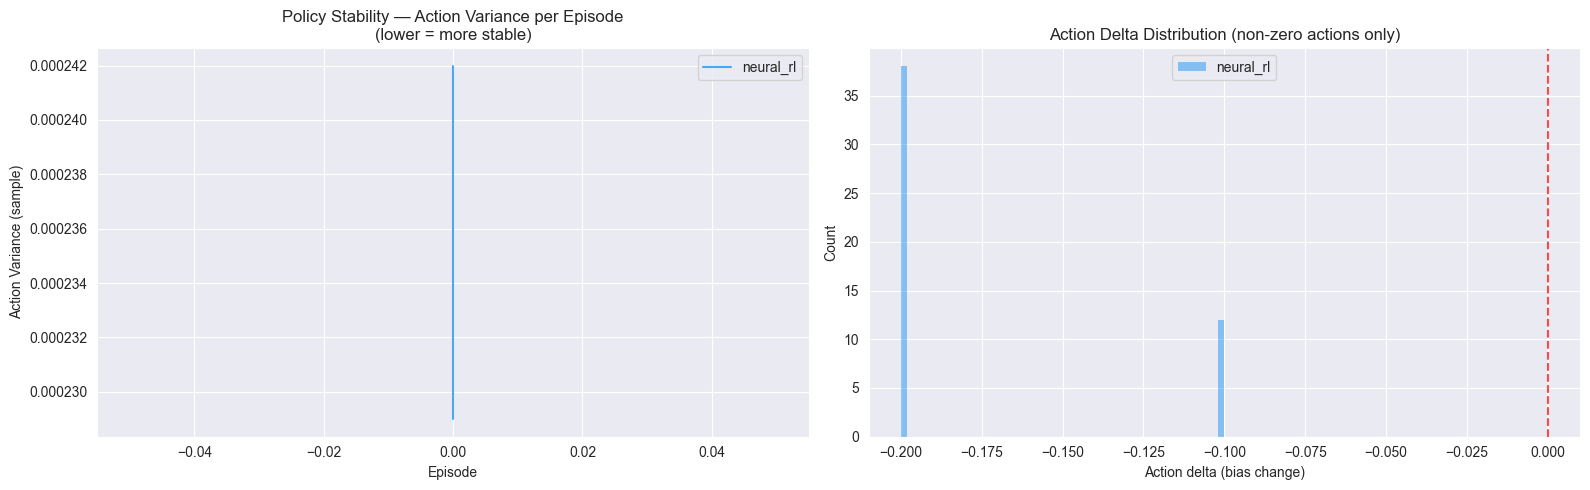

Stability summary:


,mean_action_variance,mean_return,std_return
run,,,
neural_rl,0.000236,-1765.5355,184.4057


In [7]:
if ep_data is None:
    print('Skipped — no per_episode_*.csv found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Action variance per episode
    ax = axes[0]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        if 'action_variance' in df_ep.columns:
            color = RUN_COLORS.get(run, DEFAULT_COLOR)
            ax.plot(df_ep['episode'], df_ep['action_variance'],
                    label=run, color=color, lw=1.5, alpha=0.8)
    ax.set_title('Policy Stability — Action Variance per Episode\n(lower = more stable)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Action Variance (sample)')
    ax.legend()

    # Action delta distribution per run (per-step)
    ax = axes[1]
    rl_runs_in_step = [r for r in runs if r in ['neural_rl', 'rule_based']]
    for run in rl_runs_in_step:
        subset = data[(data['run_label'] == run) & (data['action_delta'] != 0)]['action_delta']
        if len(subset) > 0:
            ax.hist(subset, bins=50, alpha=0.5,
                    color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run, edgecolor='none')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_title('Action Delta Distribution (non-zero actions only)')
    ax.set_xlabel('Action delta (bias change)')
    ax.set_ylabel('Count')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'policy_stability.png', dpi=150)
    plt.show()

    # Stability summary table
    stab_rows = []
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run]
        stab_rows.append({
            'run': run,
            'mean_action_variance': round(df_ep['action_variance'].mean(), 6)
                if 'action_variance' in df_ep.columns else 'N/A',
            'mean_return': round(df_ep['episode_return'].mean(), 4)
                if 'episode_return' in df_ep.columns else 'N/A',
            'std_return': round(df_ep['episode_return'].std(), 4)
                if 'episode_return' in df_ep.columns else 'N/A',
        })
    stab_df = pd.DataFrame(stab_rows).set_index('run')
    print('Stability summary:')
    display(stab_df)

## 6. GPU Frame Time Comparison

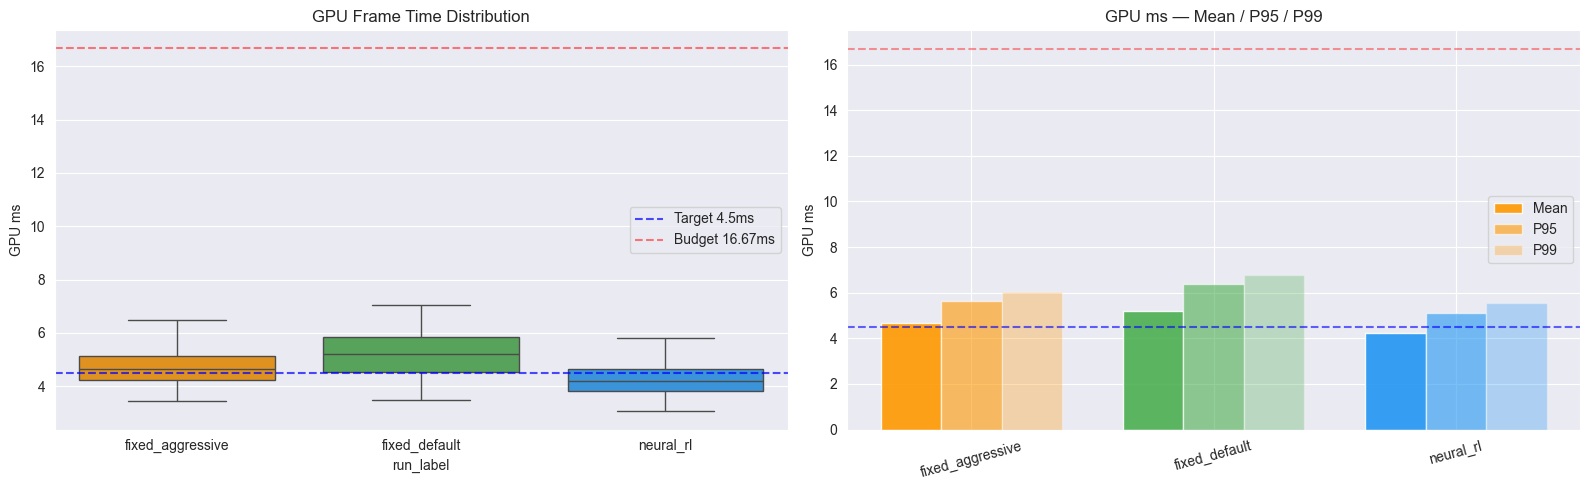

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = {r: RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs}

# Boxplot
ax = axes[0]
sns.boxplot(data=data, x='run_label', y='gpu_ms', palette=palette,
            ax=ax, showfliers=False, order=runs)
ax.axhline(T_TARGET_MS,     color='blue', linestyle='--', alpha=0.7,
           label=f'Target {T_TARGET_MS}ms')
ax.axhline(FRAME_BUDGET_MS, color='red',  linestyle='--', alpha=0.5,
           label=f'Budget {FRAME_BUDGET_MS}ms')
ax.set_title('GPU Frame Time Distribution')
ax.set_ylabel('GPU ms')
ax.legend()

# Mean/P95/P99 bar
ax = axes[1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_gpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_gpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(T_TARGET_MS,     color='blue', linestyle='--', alpha=0.6)
ax.axhline(FRAME_BUDGET_MS, color='red',  linestyle='--', alpha=0.4)
ax.set_title('GPU ms — Mean / P95 / P99')
ax.set_ylabel('GPU ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gpu_comparison.png', dpi=150)
plt.show()

## 7. FPS Stability

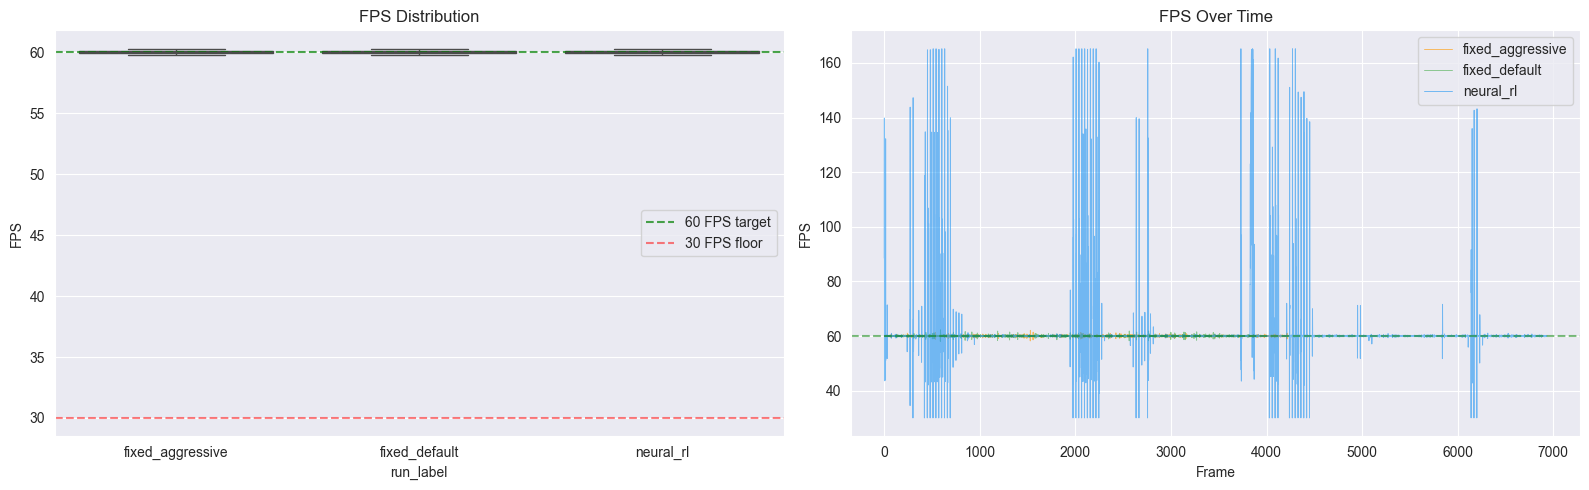

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.boxplot(data=data, x='run_label', y='fps', palette=palette,
            ax=ax, showfliers=False, order=runs)
ax.axhline(60, color='green', linestyle='--', alpha=0.7, label='60 FPS target')
ax.axhline(30, color='red',   linestyle='--', alpha=0.5, label='30 FPS floor')
ax.set_title('FPS Distribution')
ax.set_ylabel('FPS')
ax.legend()

ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run].reset_index(drop=True)
    ax.plot(subset.index, subset['fps'],
            alpha=0.6, lw=0.7,
            color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run)
ax.axhline(60, color='green', linestyle='--', alpha=0.5)
ax.set_title('FPS Over Time')
ax.set_xlabel('Frame')
ax.set_ylabel('FPS')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fps_comparison.png', dpi=150)
plt.show()

## 8. LOD Bias Distribution & Switch Rate

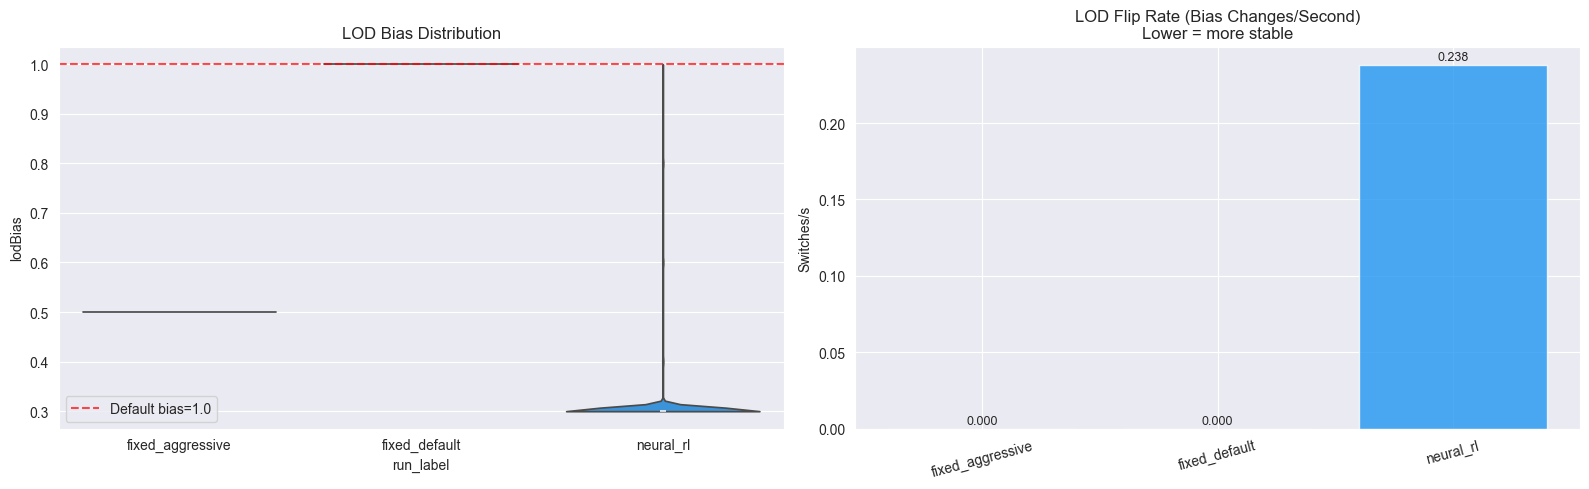

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LOD bias violin
ax = axes[0]
lod_data = data[data['lod_bias'].notna() & (data['lod_bias'] > 0)]
if len(lod_data) > 0:
    sns.violinplot(data=lod_data, x='run_label', y='lod_bias',
                   palette=palette, ax=ax, order=runs, cut=0)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Default bias=1.0')
ax.set_title('LOD Bias Distribution')
ax.set_ylabel('lodBias')
ax.legend()

# Flip rate bar
ax = axes[1]
flip_rates = [summary.loc[r, 'flip_rate_hz'] for r in runs]
colors     = [RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs]
bars = ax.bar(runs, flip_rates, color=colors, alpha=0.8, edgecolor='white')
for bar, rate in zip(bars, flip_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{rate:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('LOD Flip Rate (Bias Changes/Second)\nLower = more stable')
ax.set_ylabel('Switches/s')
ax.set_xticklabels(runs, rotation=15)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'lod_stability.png', dpi=150)
plt.show()

## 9. CDF — GPU & CPU Frame Time

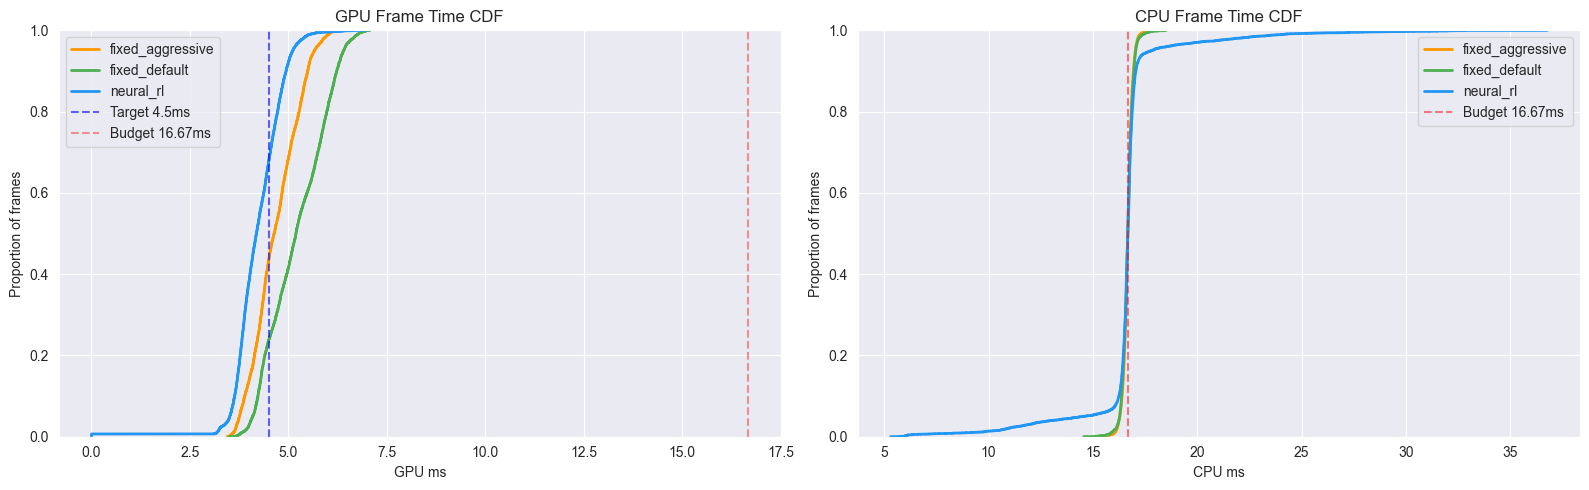

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for run in runs:
    subset = data[data['run_label'] == run]['gpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR),
                 lw=2, ax=ax)
ax.axvline(T_TARGET_MS,     color='blue', linestyle='--', alpha=0.6,
           label=f'Target {T_TARGET_MS}ms')
ax.axvline(FRAME_BUDGET_MS, color='red',  linestyle='--', alpha=0.4,
           label=f'Budget {FRAME_BUDGET_MS}ms')
ax.set_title('GPU Frame Time CDF')
ax.set_xlabel('GPU ms')
ax.set_ylabel('Proportion of frames')
ax.legend()

ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run]['cpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR),
                 lw=2, ax=ax)
ax.axvline(FRAME_BUDGET_MS, color='red', linestyle='--', alpha=0.5,
           label=f'Budget {FRAME_BUDGET_MS}ms')
ax.set_title('CPU Frame Time CDF')
ax.set_xlabel('CPU ms')
ax.set_ylabel('Proportion of frames')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_cdf.png', dpi=150)
plt.show()

## 10. Generalization (RL Metric 3)
Compares GPU frame time CDF on the training camera path vs. a held-out path.  
Run `RLEvaluationLogger` with `runLabel = "neural_rl_held_out"` on different camera path nodes.  
A robust policy shows similar GPU distributions across paths.

In [12]:
# Check for held-out path run
HELD_OUT_LABEL = 'neural_rl_held_out'
TRAIN_LABEL    = 'neural_rl'

gen_runs = [r for r in runs if r in [TRAIN_LABEL, HELD_OUT_LABEL]]

if len(gen_runs) < 2:
    print(f'Generalization plot skipped — need both "{TRAIN_LABEL}" and "{HELD_OUT_LABEL}" runs.')
    print('To generate held-out data: change camera path nodes in Unity, '
          f'set runLabel = "{HELD_OUT_LABEL}", run scene, copy per_step CSV here.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # GPU CDF comparison
    ax = axes[0]
    for run in gen_runs:
        subset = data[data['run_label'] == run]['gpu_ms'].dropna()
        sns.ecdfplot(subset, label=run, ax=ax, lw=2,
                     color=RUN_COLORS.get(run, DEFAULT_COLOR))
    ax.axvline(T_TARGET_MS, color='red', linestyle='--', alpha=0.6)
    ax.set_title('Generalization — GPU Time CDF\n(train vs. held-out path)')
    ax.set_xlabel('GPU ms')
    ax.legend()

    # LOD bias distribution
    ax = axes[1]
    for run in gen_runs:
        subset = data[data['run_label'] == run]['lod_bias'].dropna()
        ax.hist(subset, bins=40, alpha=0.5,
                color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run, edgecolor='none')
    ax.set_title('LOD Bias Distribution\n(train vs. held-out path)')
    ax.set_xlabel('lodBias')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'generalization.png', dpi=150)
    plt.show()

Generalization plot skipped — need both "neural_rl" and "neural_rl_held_out" runs.
To generate held-out data: change camera path nodes in Unity, set runLabel = "neural_rl_held_out", run scene, copy per_step CSV here.


## 11. ROI — GPU Savings vs Neural Overhead

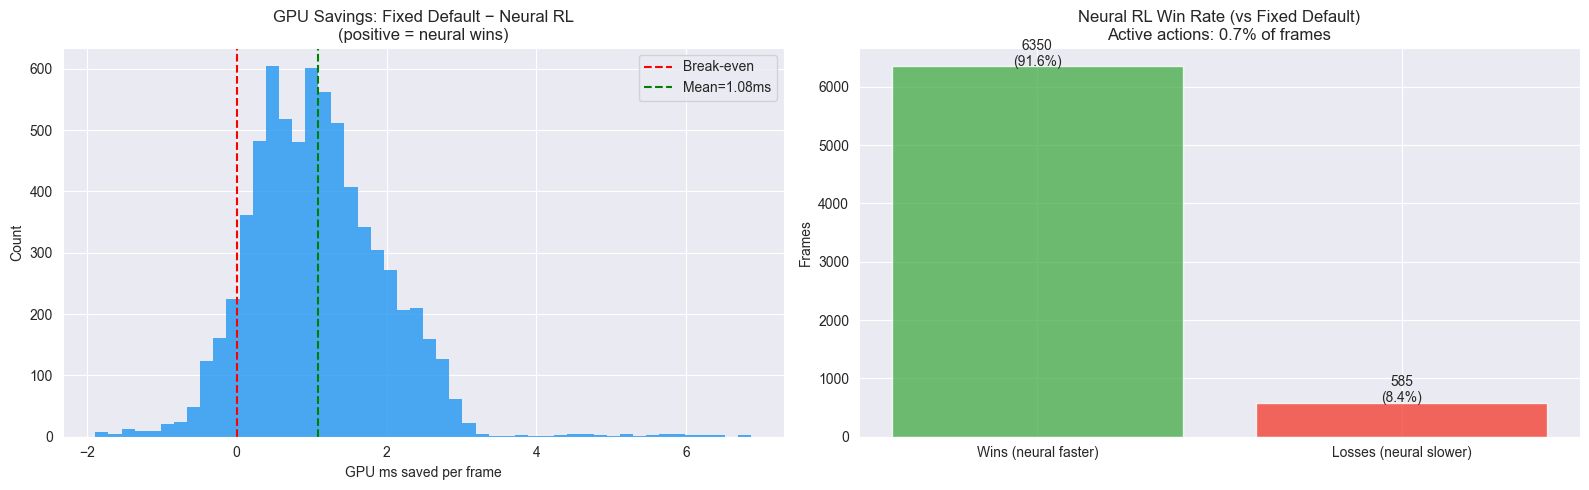

In [13]:
if 'neural_rl' in runs and 'fixed_default' in runs:
    neural_df = data[data['run_label'] == 'neural_rl'][['frame', 'gpu_ms']].copy()
    base_df   = data[data['run_label'] == 'fixed_default'][['frame', 'gpu_ms']].copy()

    merged = pd.merge(neural_df, base_df, on='frame', suffixes=('_neural', '_base'))
    gpu_savings = merged['gpu_ms_base'] - merged['gpu_ms_neural']

    # Action overhead proxy: action_delta != 0 frames
    neural_steps = data[data['run_label'] == 'neural_rl']
    active_pct   = 100 * (neural_steps['action_delta'].abs() > 0.001).mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.hist(gpu_savings, bins=50, color='#2196F3', alpha=0.8, edgecolor='none')
    ax.axvline(0,              color='red',   linestyle='--', label='Break-even')
    ax.axvline(gpu_savings.mean(), color='green', linestyle='--',
               label=f'Mean={gpu_savings.mean():.2f}ms')
    ax.set_title('GPU Savings: Fixed Default − Neural RL\n(positive = neural wins)')
    ax.set_xlabel('GPU ms saved per frame')
    ax.set_ylabel('Count')
    ax.legend()

    ax = axes[1]
    categories = ['Wins (neural faster)', 'Losses (neural slower)']
    counts = [(gpu_savings > 0).sum(), (gpu_savings <= 0).sum()]
    ax.bar(categories, counts,
           color=['#4CAF50', '#F44336'], alpha=0.8, edgecolor='white')
    for i, (cat, cnt) in enumerate(zip(categories, counts)):
        ax.text(i, cnt + 5, f'{cnt}\n({100*cnt/len(gpu_savings):.1f}%)',
                ha='center', fontsize=10)
    ax.set_title(f'Neural RL Win Rate (vs Fixed Default)\nActive actions: {active_pct:.1f}% of frames')
    ax.set_ylabel('Frames')

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'roi_analysis.png', dpi=150)
    plt.show()
else:
    print('ROI analysis skipped — need both "neural_rl" and "fixed_default" runs.')

## 12. Final Report Table

In [14]:
report_cols = [
    'frames', 'mean_cpu_ms', 'p95_cpu_ms', 'p99_cpu_ms',
    'mean_gpu_ms', 'p95_gpu_ms', 'p99_gpu_ms',
    'mean_fps', 'p5_fps',
    'mean_lod_bias', 'action_std',
    'lod_switches', 'flip_rate_hz', 'over_budget_pct',
    'mean_screen_cov'
]
report = summary[[c for c in report_cols if c in summary.columns]]
print('=== Final Evaluation Report ===')
display(report.T)

report.to_csv(PLOTS_DIR / 'eval_summary_report.csv')
print(f'\nSaved: {PLOTS_DIR / "eval_summary_report.csv"}')

# Neural vs Fixed Default delta
if 'neural_rl' in runs and 'fixed_default' in runs:
    print('\n=== Neural RL vs Fixed Default ===')
    for metric in ['mean_gpu_ms', 'mean_fps', 'over_budget_pct', 'flip_rate_hz']:
        if metric not in summary.columns:
            continue
        n  = summary.loc['neural_rl',     metric]
        f  = summary.loc['fixed_default', metric]
        d  = n - f
        pct_d = 100 * d / f if f != 0 else 0
        direction = 'higher' if d > 0 else 'lower'
        print(f'  {metric:25s}: neural={n:.3f}  fixed={f:.3f}  delta={d:+.3f} ({pct_d:+.1f}% {direction})')

print('\n=== RL Metrics Summary ===')
if ep_data is not None and 'neural_rl' in ep_data['run_label'].values:
    rl_ep = ep_data[ep_data['run_label'] == 'neural_rl']
    if 'episode_return' in rl_ep.columns:
        print(f'  Reward convergence | mean_return={rl_ep["episode_return"].mean():.4f} '
              f'| last_5_mean={rl_ep["episode_return"].tail(5).mean():.4f}')
    if 'action_variance' in rl_ep.columns:
        print(f'  Policy stability   | mean_action_var={rl_ep["action_variance"].mean():.6f} '
              f'| last_5_mean={rl_ep["action_variance"].tail(5).mean():.6f}')
    print(f'  Generalization     | run held-out path with label "{HELD_OUT_LABEL}" '
          f'and compare GPU CDF (Section 10)')
else:
    print('  No per-episode data — run Unity with RLEvaluationLogger to populate.')

=== Final Evaluation Report ===


run_label,fixed_aggressive,fixed_default,neural_rl
frames,4225.000,3914.000,6935.0000
mean_cpu_ms,16.666,16.666,16.6250
p95_cpu_ms,17.032,17.048,17.8060
p99_cpu_ms,17.250,17.390,24.0860
mean_gpu_ms,4.683,5.218,4.2250
p95_gpu_ms,5.657,6.402,5.1100
p99_gpu_ms,6.021,6.761,5.5480
mean_fps,60.000,60.000,61.2400
p5_fps,59.740,59.730,59.6300
mean_lod_bias,0.500,1.000,0.3050



Saved: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Eval\eval_summary_report.csv

=== Neural RL vs Fixed Default ===
  mean_gpu_ms              : neural=4.225  fixed=5.218  delta=-0.993 (-19.0% lower)
  mean_fps                 : neural=61.240  fixed=60.000  delta=+1.240 (+2.1% higher)
  over_budget_pct          : neural=49.200  fixed=49.800  delta=-0.600 (-1.2% lower)
  flip_rate_hz             : neural=0.238  fixed=0.000  delta=+0.238 (+0.0% higher)

=== RL Metrics Summary ===
  Reward convergence | mean_return=-1765.5355 | last_5_mean=-1765.5355
  Policy stability   | mean_action_var=0.000236 | last_5_mean=0.000236
  Generalization     | run held-out path with label "neural_rl_held_out" and compare GPU CDF (Section 10)
